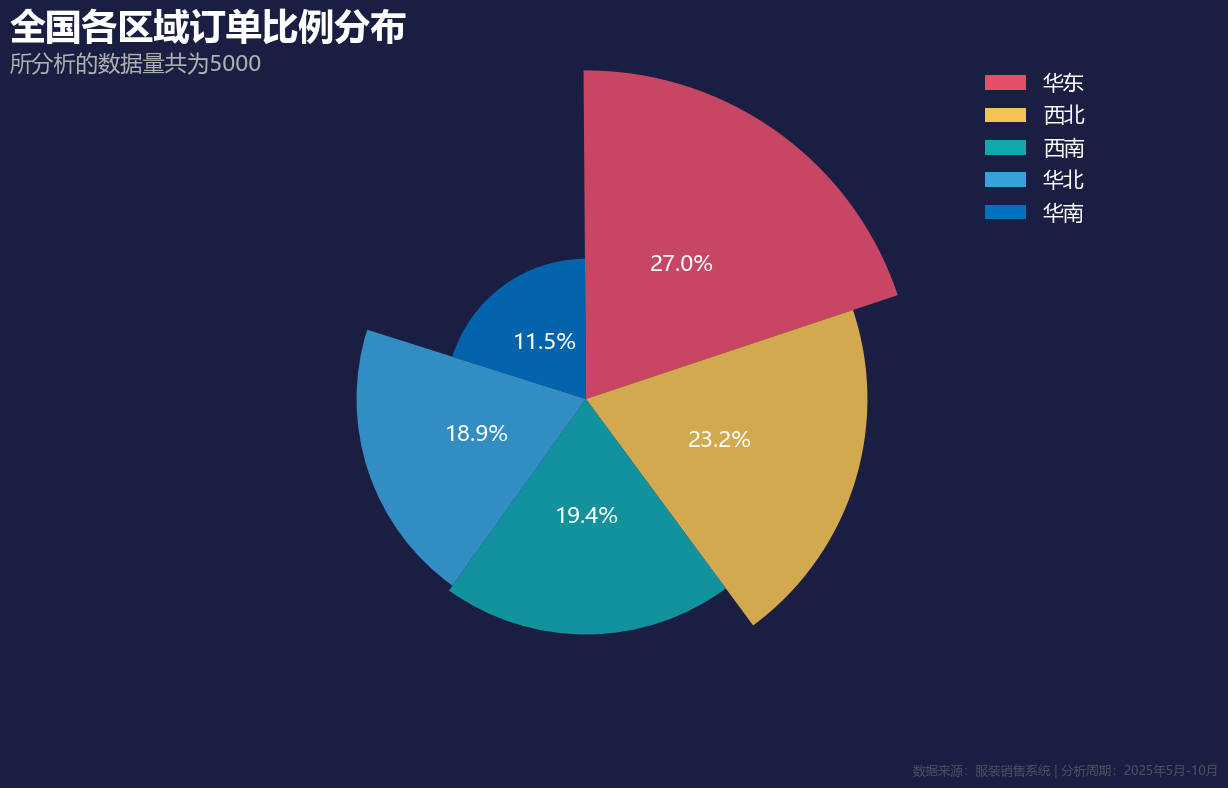

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 区域划分映射
REGION_MAPPING = {
    '华北': ['北京市', '天津市', '河北省', '山西省', '内蒙古自治区'],
    '华东': ['上海市', '江苏省', '浙江省', '安徽省', '福建省', '江西省', '山东省'],
    '华南': ['广东省', '广西壮族自治区', '海南省'],
    '华中': ['河南省', '湖北省', '湖南省'],
    '西南': ['重庆市', '四川省', '贵州省', '云南省', '西藏自治区'],
    '西北': ['陕西省', '甘肃省', '青海省', '宁夏回族自治区', '新疆维吾尔自治区'],
}

# 指定颜色方案
COLORS = [
    "#e74e69",  # 粉红
    "#f5c353",  # 金黄
    "#11a7ad",  # 青蓝
    "#37a2da",  # 蓝
    "#0070c0",  # 深蓝
    "#7030a0"   # 紫
]

try:
    # 严格读取CSV文件
    df_orders = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['省份']
    for col in required_columns:
        if col not in df_orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 数据清洗
    if df_orders['省份'].isnull().all():
        raise ValueError("省份数据全部为空")
    
    # 清洗无效省份数据
    df_orders = df_orders[df_orders['省份'].notnull()]
    if df_orders.empty:
        raise ValueError("没有有效的省份数据")
    
    # 映射区域
    def map_region(province):
        for region, provinces in REGION_MAPPING.items():
            if province in provinces:
                return region
        return '其他'
    
    df_orders['区域'] = df_orders['省份'].apply(map_region)
    
    # 计算各区域订单量
    region_orders = df_orders.groupby('区域').size().reset_index(name='订单量')
    
    # 仅保留六大区域
    main_regions = ['华北', '华东', '华南', '西南', '西北']
    region_orders = region_orders[region_orders['区域'].isin(main_regions)]
    
    # 按订单量降序排列
    region_orders = region_orders.sort_values(by='订单量', ascending=False)

    if region_orders.empty:
        raise ValueError("没有符合条件的区域数据")
    
    # 计算各区域的订单比例
    region_orders['比例'] = region_orders['订单量'] / region_orders['订单量'].sum()
    
    # 创建南丁格尔玫瑰图
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': 'polar'}, dpi=100)
    
    # 设置深蓝色背景
    fig.patch.set_facecolor('#1A1E43')
    ax.set_facecolor('#1A1E43')
    
    # 隐藏坐标轴
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置0度在90度位置，顺时针方向
    ax.set_theta_offset(0.95)
    ax.set_theta_direction(-1)
    
    # 计算角度和半径
    num_regions = len(region_orders)
    angles = np.linspace(0, 2*np.pi, num_regions, endpoint=False)
    widths = np.full(num_regions, 2*np.pi / num_regions)
    
    # 计算归一化的半径
    max_count = region_orders['订单量'].max()
    radii = region_orders['订单量'] / max_count * 0.9
    
    # 绘制南丁格尔玫瑰图
    bars = ax.bar(angles, radii, width=widths, 
                color=COLORS, 
                edgecolor=None,
                linewidth=0.5,
                alpha=0.85)
    
    # 添加比例标签，放置在圆内
    for i, (angle, radius, ratio) in enumerate(zip(angles, radii, region_orders['比例'])):
        # 设置比例文本的半径位置，确保在圆内展示
        text_radius = radius / 2
        ax.text(angle, 
                text_radius,
                f'{ratio:.1%}',
                ha='center',
                va='center',
                color='white',
                fontsize=16)
    
    # 创建图例
    legend_labels = region_orders['区域'].tolist()
    legend_patches = [Patch(facecolor=COLORS[i], label=legend_labels[i]) for i in range(len(legend_labels))]
    
    ax.legend(handles=legend_patches,
            loc='upper right',
            bbox_to_anchor=(1.25, 1.0),
            frameon=False,
            labelcolor='#ffffff',
            fontsize=15)

    # 设置标题
    plt.figtext(0.02, 0.95, "全国各区域订单比例分布",
                ha='left', fontsize=26, color='#ffffff', fontweight='bold')
    plt.figtext(0.02, 0.91, f"所分析的数据量共为{len(df_orders)}", 
                ha='left', fontsize=16, color='#B0B0B0')
    
    # 添加底部说明
    plt.figtext(0.9, 0.03, 
                '数据来源：服装销售系统 | 分析周期：2025年5月-10月', 
                ha='center', 
                fontsize=9, 
                color='#666666',
                alpha=0.7)

    # 调整布局
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('全国各区域订单比例分布.png', 
                dpi=300, 
                bbox_inches='tight',
                facecolor=fig.get_facecolor())
    
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **华东区域**（红色）：
  占比最高，达到27.0%，表明华东区域在订单分布中占据主导地位，可能与该区域的经济活跃度和人口密度有关。

- **西北区域**（金黄色）：
  占比23.2%，位居第二，显示出西北区域在订单分布中的重要性，可能反映了该区域市场的增长潜力。

- **西南区域**（青蓝色）：
  占比19.4%，位于第三位，表明西南区域的市场表现稳定，可能与该区域的特定消费需求相关。

- **华北区域**（浅蓝色）：
  占比18.9%，略低于西南区域，显示出华北区域的市场活跃度，可能与该区域的经济发展水平有关。

- **华南区域**（深蓝色）：
  占比最小，为11.5%，可能反映了华南区域在订单分布中的相对劣势，需要进一步分析原因。


# 结论

从全国各区域订单比例分布来看，华东和西北区域在市场中表现最为突出，显示出其强大的市场吸引力和用户基础。西南和华北区域也显示出较强的市场潜力，而华南区域的订单比例相对较低，可能需要进一步分析其市场策略和用户定位。